# AVIRENZA Technologies – AI/ML Internship
## Task 4: Electricity Consumption Prediction with Feature Engineering & Model Improvement
**Student:** Tharani Natarajan  
**College:** IFET College of Engineering  
**Department:** Artificial Intelligence and Data Science  
**Task Type:** Supervised Machine Learning – Regression


## 1. Project Objective & Scope
The primary purpose of this project is to systematically demonstrate how **domain-specific feature engineering** (lag observations, rolling statistics, cyclical encodings, and temporal markers) and **model improvement strategies** (transitioning from baseline linear algorithms to non-linear tree ensembles with time-aware hyperparameter tuning) substantially enhance predictive performance on continuous electricity consumption time series.

### Key Objectives:
1. Establish a simple, realistic baseline model using basic temporal and raw electrical features.
2. Formulate advanced engineered features:
   - **Temporal indicators:** `hour`, `day_of_week`, `month`, `day_of_year`, `quarter`, `is_weekend`, `is_peak_hour`.
   - **Cyclical features:** Sine and Cosine transformations for `hour`, `day_of_week`, and `month`.
   - **Historical Lag features:** Past power consumption values at 1h, 2h, 3h, 24h, 48h, and 168h (1 week) prior.
   - **Rolling window statistics:** 24h rolling mean, standard deviation, minimum, maximum, and 168h rolling mean.
3. Strictly prevent **data leakage**:
   - Apply `shift(1)` before computing rolling metrics so the current observation is never used to predict itself.
   - Employ chronological train/test splitting (first 80% train, subsequent 20% test) without random shuffling.
4. Implement `TimeSeriesSplit` cross-validation and hyperparameter tuning.
5. Quantify gains in MAE, RMSE, and $R^2$, and conduct in-depth residual and error analyses.


## 2. Dataset Information
- **Dataset:** UCI Individual Household Electric Power Consumption Dataset
- **Official Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)
- **Timeframe:** December 2006 to November 2010 (47 months)
- **Sampling:** Resampled to hourly intervals (`household_power_consumption_hourly.csv`, 34,589 total hourly records)
- **Target Variable:** `Global_active_power` (kilowatts)


## 3. Environment Setup & Library Imports


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

print("All dependencies loaded successfully!")


All dependencies loaded successfully!


## 4. Load and Inspect Hourly Electricity Consumption Data


In [2]:
# Locate hourly dataset
data_path = Path('../data/household_power_consumption_hourly.csv')
if not data_path.exists():
    data_path = Path('data/household_power_consumption_hourly.csv')

df = pd.read_csv(data_path, index_col='Datetime', parse_dates=True)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df.index.min()} to {df.index.max()}")
display(df.head())


Dataset shape: 34589 rows, 7 columns
Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [3]:
# Summary statistics and missing values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Numerical Statistics ---")
display(df.describe().T)


--- Missing Values ---
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

--- Numerical Statistics ---


,count,mean,std,min,25%,50%,75%,max
Global_active_power,34589.0,1.092488,0.895746,0.124000,0.343433,0.806833,1.578233,6.560533
Global_reactive_power,34589.0,0.123710,0.066998,0.000000,0.078067,0.106833,0.149367,0.774333
Voltage,34589.0,240.828386,3.002928,225.834500,239.174833,240.974667,242.687667,251.902000
Global_intensity,34589.0,4.631340,3.749644,0.503333,1.520000,3.436667,6.600000,28.383333
Sub_metering_1,34589.0,1.123029,3.534985,0.000000,0.000000,0.000000,0.000000,48.366667
Sub_metering_2,34589.0,1.291784,4.170525,0.000000,0.000000,0.333333,0.650000,46.433333
Sub_metering_3,34589.0,6.445877,7.332015,0.000000,0.650000,1.666667,14.066667,21.550000


## 5. Exploratory Data Analysis & Consumption Patterns


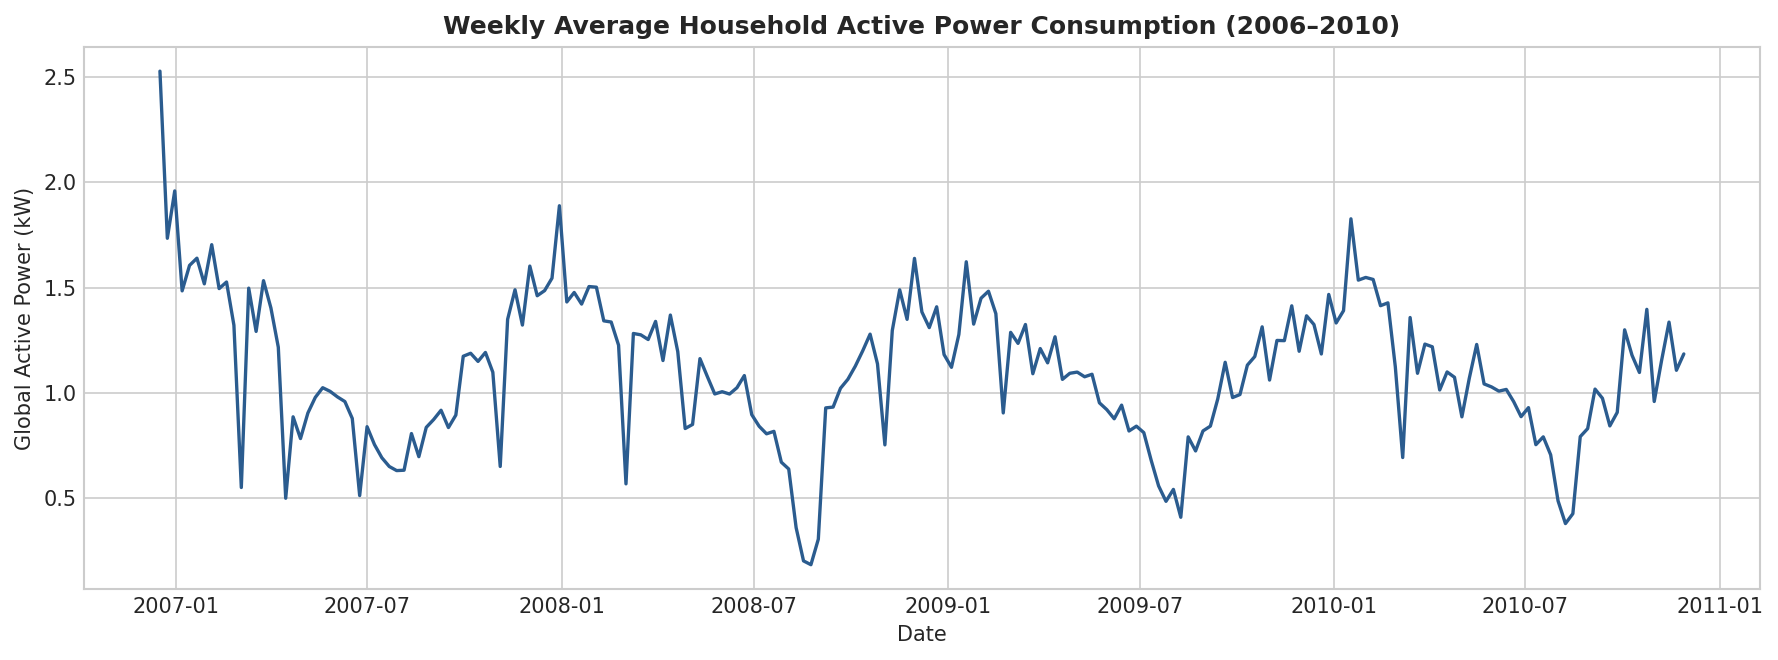

In [4]:
# 1. Weekly Average Consumption Trend
plt.figure(figsize=(12, 4.5), dpi=150)
df_weekly = df['Global_active_power'].resample('W').mean()
plt.plot(df_weekly.index, df_weekly.values, color='#2b5c8f', lw=1.6)
plt.title('Weekly Average Household Active Power Consumption (2006–2010)', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()


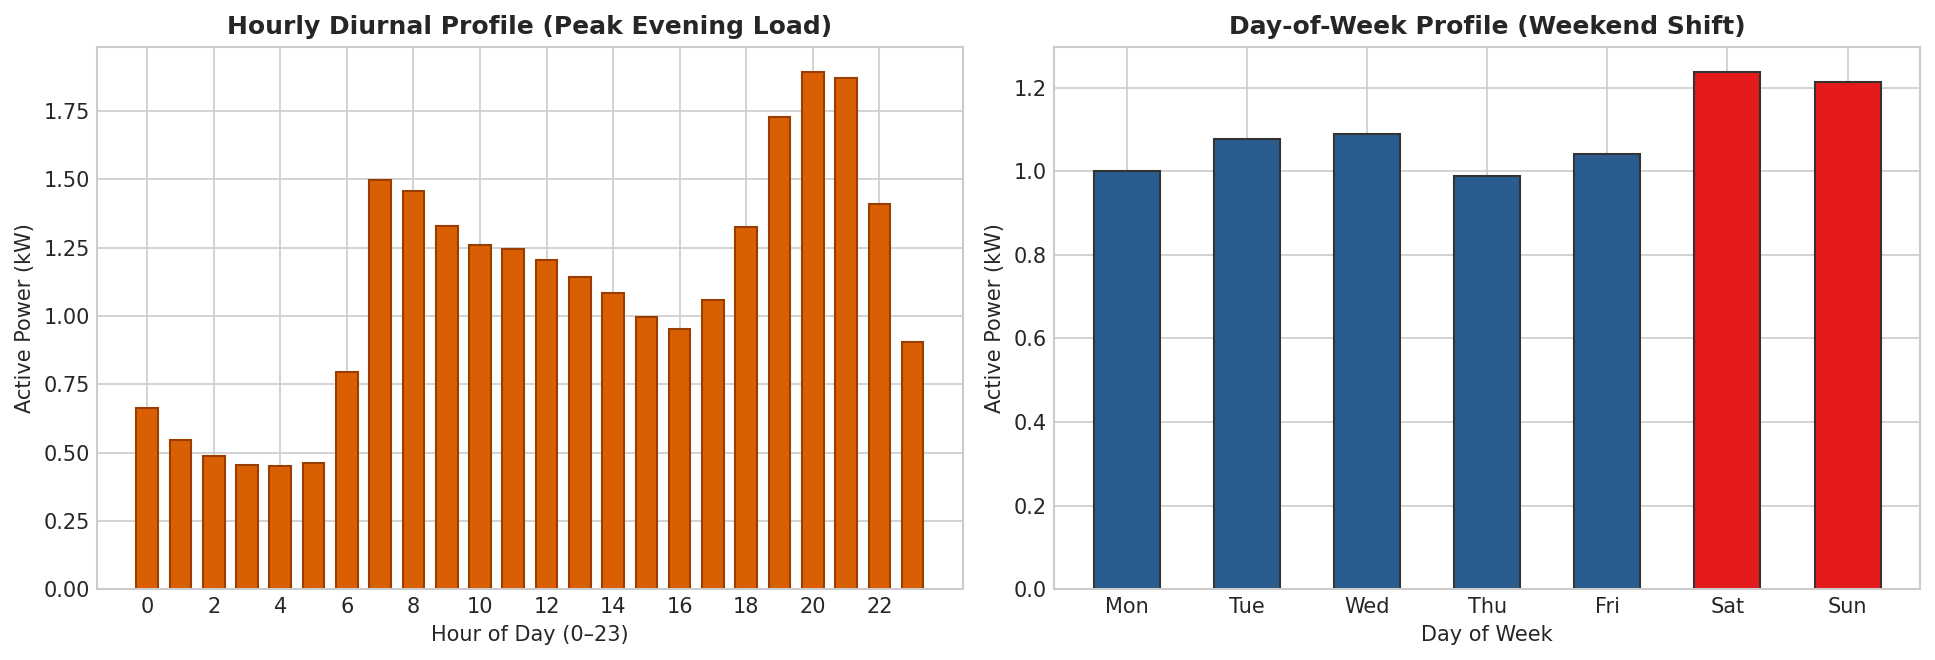

In [5]:
# 2. Average Hourly & Day of Week Profile
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)

# Hourly Profile
hourly_avg = df.groupby(df.index.hour)['Global_active_power'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='#d95f02', edgecolor='#993d00', width=0.65)
axes[0].set_title('Hourly Diurnal Profile (Peak Evening Load)', fontweight='bold')
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Active Power (kW)')
axes[0].set_xticks(range(0, 24, 2))

# Day of Week Profile
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = df.groupby(df.index.dayofweek)['Global_active_power'].mean()
colors = ['#2b5c8f' if i < 5 else '#e41a1c' for i in range(7)]
axes[1].bar(days, dow_avg.values, color=colors, edgecolor='#333333', width=0.55)
axes[1].set_title('Day-of-Week Profile (Weekend Shift)', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Active Power (kW)')

plt.tight_layout()
plt.show()


## 6. Advanced Feature Engineering & Leakage Prevention
To capture non-linear patterns, autocorrelation, and seasonal swings, we generate 4 key categories of engineered features:
1. **Calendar / Temporal Features:** Hours, days, months, and binary peak consumption indicator.
2. **Cyclical Sine/Cosine Features:** Smooth continuous periodicity ensuring hour 23 and hour 0 are mathematically adjacent.
3. **Historical Lag Features:** Target values at $t-1, t-2, t-3, t-24, t-48, t-168$.
4. **Rolling Window Statistics:** 24h & 168h rolling statistics calculated strictly on `shift(1)` to prevent target leakage.


In [6]:
# Construct engineered feature sets
df_fe = df.copy()

# 1. Temporal indicators
df_fe['hour'] = df_fe.index.hour
df_fe['day_of_week'] = df_fe.index.dayofweek
df_fe['month'] = df_fe.index.month
df_fe['day_of_year'] = df_fe.index.dayofyear
df_fe['quarter'] = df_fe.index.quarter
df_fe['is_weekend'] = (df_fe.index.dayofweek >= 5).astype(int)
df_fe['is_peak_hour'] = df_fe['hour'].isin([18, 19, 20, 21, 22]).astype(int)

# 2. Cyclical encodings
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24.0)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24.0)
df_fe['day_of_week_sin'] = np.sin(2 * np.pi * df_fe['day_of_week'] / 7.0)
df_fe['day_of_week_cos'] = np.cos(2 * np.pi * df_fe['day_of_week'] / 7.0)
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12.0)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12.0)

# 3. Lag features
target_col = 'Global_active_power'
for lag in [1, 2, 3, 24, 48, 168]:
    df_fe[f'lag_{lag}'] = df_fe[target_col].shift(lag)

# 4. Rolling features (strictly on shifted target to avoid leakage)
shifted_target = df_fe[target_col].shift(1)
df_fe['rolling_mean_24'] = shifted_target.rolling(24).mean()
df_fe['rolling_std_24'] = shifted_target.rolling(24).std()
df_fe['rolling_min_24'] = shifted_target.rolling(24).min()
df_fe['rolling_max_24'] = shifted_target.rolling(24).max()
df_fe['rolling_mean_168'] = shifted_target.rolling(168).mean()

# Drop initial NaN rows created by the 168h lag and windowing
df_fe = df_fe.dropna()
print(f"Cleaned Feature-Engineered Dataset Shape: {df_fe.shape}")


Cleaned Feature-Engineered Dataset Shape: (34421, 31)


## 7. Chronological Train-Test Split
In time series forecasting, using a random `train_test_split` with shuffling causes catastrophic future lookahead leakage. We enforce strict chronological partitioning:
- **Training Set:** First 80% of historical records
- **Test Set:** Subsequent 20% future records


In [7]:
# Feature columns selection
exclude_cols = ['Global_active_power', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
fe_cols = [c for c in df_fe.columns if c not in exclude_cols]
baseline_cols = ['hour', 'day_of_week', 'month', 'Voltage', 'Global_reactive_power']

split_idx = int(len(df_fe) * 0.80)
train_df = df_fe.iloc[:split_idx]
test_df = df_fe.iloc[split_idx:]

# Baseline data splits
X_tr_b = train_df[baseline_cols]
X_te_b = test_df[baseline_cols]

# Engineered feature data splits
X_tr_fe = train_df[fe_cols]
X_te_fe = test_df[fe_cols]

# Target splits
y_tr = train_df[target_col]
y_te = test_df[target_col]

print(f"Engineered Features ({len(fe_cols)}): {fe_cols}")
print(f"Training Period: {train_df.index.min()} to {train_df.index.max()} ({len(train_df)} samples)")
print(f"Testing Period : {test_df.index.min()} to {test_df.index.max()} ({len(test_df)} samples)")


Engineered Features (26): ['Global_reactive_power', 'Voltage', 'hour', 'day_of_week', 'month', 'day_of_year', 'quarter', 'is_weekend', 'is_peak_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24', 'rolling_mean_168']
Training Period: 2006-12-23 17:00:00 to 2010-02-13 00:00:00 (27536 samples)
Testing Period : 2010-02-13 01:00:00 to 2010-11-26 21:00:00 (6885 samples)


## 8. Model Training: Baseline vs. Improved Models
We compare three distinct setups:
1. **Model 1 (Baseline):** Linear Regression trained on 5 simple features.
2. **Model 2 (Improved):** Random Forest Regressor with 26 engineered features.
3. **Model 3 (Tuned):** Random Forest optimized with `TimeSeriesSplit` cross-validation.


In [8]:
# 1. Train Baseline Linear Regression
lr_base = LinearRegression()
lr_base.fit(X_tr_b, y_tr)
y_pred_base = lr_base.predict(X_te_b)

mae_b = mean_absolute_error(y_te, y_pred_base)
rmse_b = np.sqrt(mean_squared_error(y_te, y_pred_base))
r2_b = r2_score(y_te, y_pred_base)

print(f"--- Baseline Linear Regression ---")
print(f"MAE : {mae_b:.4f} kW")
print(f"RMSE: {rmse_b:.4f} kW")
print(f"R²  : {r2_b:.4f}")


--- Baseline Linear Regression ---
MAE : 0.5179 kW
RMSE: 0.6382 kW
R²  : 0.2299


In [9]:
# 2. Train Improved Random Forest (with FE)
rf_fe = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_fe.fit(X_tr_fe, y_tr)
y_pred_rf = rf_fe.predict(X_te_fe)

mae_rf = mean_absolute_error(y_te, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_te, y_pred_rf))
r2_rf = r2_score(y_te, y_pred_rf)

print(f"--- Improved Random Forest (FE) ---")
print(f"MAE : {mae_rf:.4f} kW ({(mae_b - mae_rf)/mae_b * 100:.1f}% improvement)")
print(f"RMSE: {rmse_rf:.4f} kW ({(rmse_b - rmse_rf)/rmse_b * 100:.1f}% improvement)")
print(f"R²  : {r2_rf:.4f} (surge from {r2_b:.4f})")


--- Improved Random Forest (FE) ---
MAE : 0.3064 kW (40.8% improvement)
RMSE: 0.4443 kW (30.4% improvement)
R²  : 0.6267 (surge from 0.2299)


In [10]:
# 3. TimeSeriesSplit Hyperparameter Tuning
tscv = TimeSeriesSplit(n_splits=3)
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [12, 16],
    'min_samples_split': [4, 8]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_tr_fe, y_tr)
tuned_rf = grid_rf.best_estimator_

y_pred_tuned = tuned_rf.predict(X_te_fe)
mae_tuned = mean_absolute_error(y_te, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_te, y_pred_tuned))
r2_tuned = r2_score(y_te, y_pred_tuned)

print(f"Optimal Parameters: {grid_rf.best_params_}")
print(f"--- Tuned Random Forest ---")
print(f"MAE : {mae_tuned:.4f} kW")
print(f"RMSE: {rmse_tuned:.4f} kW")
print(f"R²  : {r2_tuned:.4f}")


Optimal Parameters: {'max_depth': 16, 'min_samples_split': 4, 'n_estimators': 150}
--- Tuned Random Forest ---
MAE : 0.3063 kW
RMSE: 0.4433 kW
R²  : 0.6284


## 9. Model Evaluation & Comparison


In [11]:
comparison_df = pd.DataFrame([
    {
        'Model': 'Baseline Linear Regression',
        'Features': len(baseline_cols),
        'MAE (kW)': round(mae_b, 4),
        'RMSE (kW)': round(rmse_b, 4),
        'R² Score': round(r2_b, 4),
        'MAE Reduction (%)': '0.0%',
        'RMSE Reduction (%)': '0.0%'
    },
    {
        'Model': 'Improved Random Forest (FE)',
        'Features': len(fe_cols),
        'MAE (kW)': round(mae_rf, 4),
        'RMSE (kW)': round(rmse_rf, 4),
        'R² Score': round(r2_rf, 4),
        'MAE Reduction (%)': f"{(mae_b - mae_rf)/mae_b * 100:.1f}%",
        'RMSE Reduction (%)': f"{(rmse_b - rmse_rf)/rmse_b * 100:.1f}%"
    },
    {
        'Model': 'Tuned Random Forest',
        'Features': len(fe_cols),
        'MAE (kW)': round(mae_tuned, 4),
        'RMSE (kW)': round(rmse_tuned, 4),
        'R² Score': round(r2_tuned, 4),
        'MAE Reduction (%)': f"{(mae_b - mae_tuned)/mae_b * 100:.1f}%",
        'RMSE Reduction (%)': f"{(rmse_b - rmse_tuned)/rmse_b * 100:.1f}%"
    }
])
display(comparison_df)


,Model,Features,MAE (kW),RMSE (kW),R² Score,MAE Reduction (%),RMSE Reduction (%)
0,Baseline Linear Regression,5,0.5179,0.6382,0.2299,0.0%,0.0%
1,Improved Random Forest (FE),26,0.3064,0.4443,0.6267,40.8%,30.4%
2,Tuned Random Forest,26,0.3063,0.4433,0.6284,40.8%,30.5%


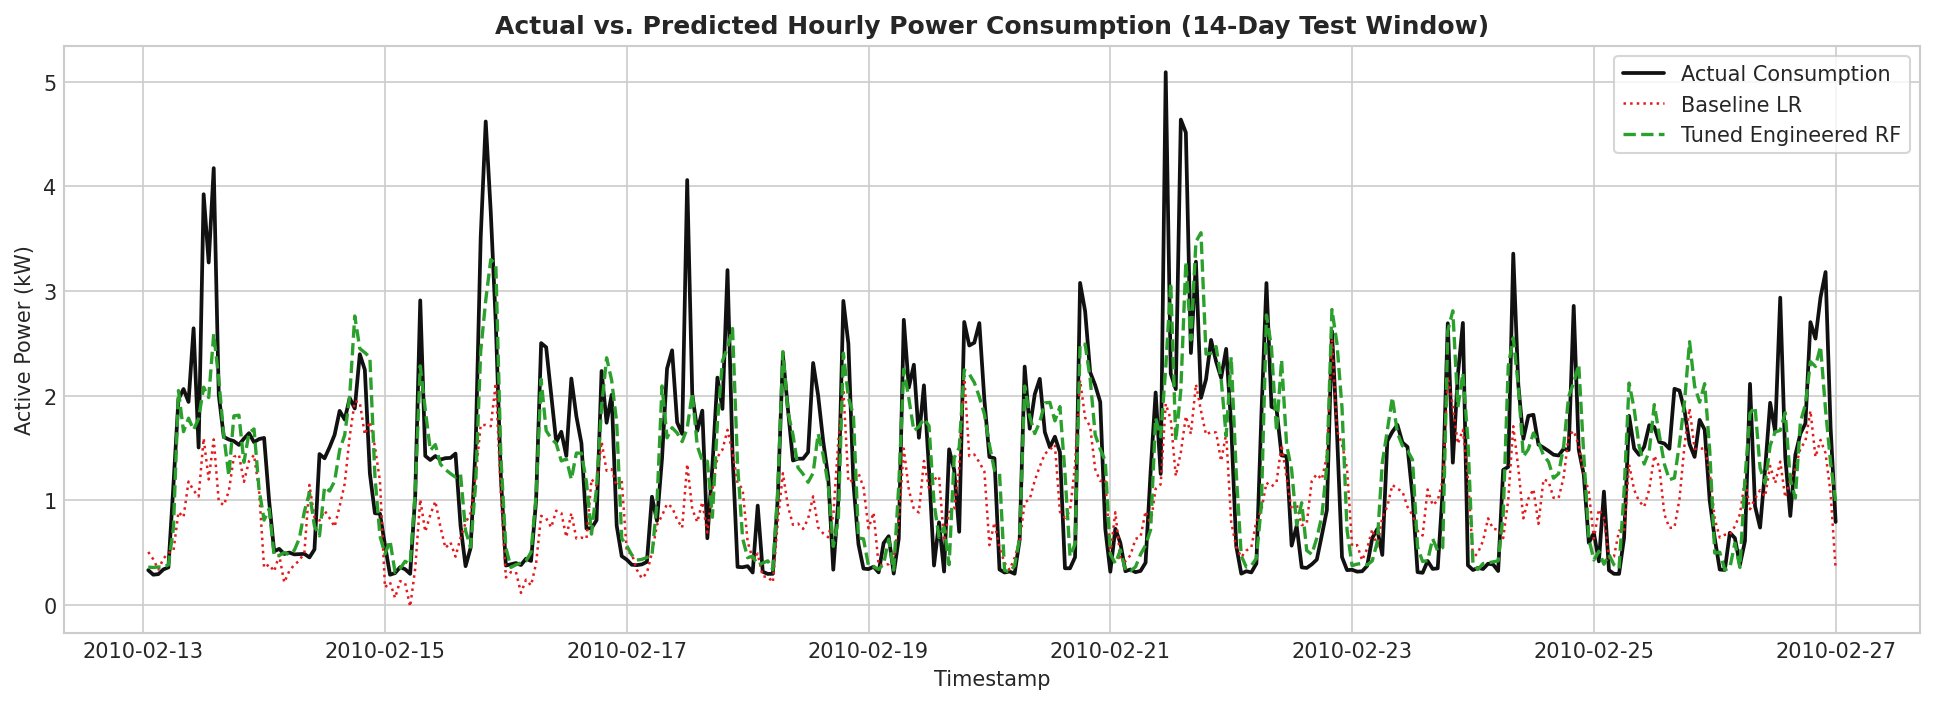

In [12]:
# Actual vs Predicted 14-Day Visual Window
plt.figure(figsize=(13, 4.8), dpi=150)
zoom = 336
t_idx = y_te.index[:zoom]
plt.plot(t_idx, y_te.iloc[:zoom].values, label='Actual Consumption', color='#111111', lw=1.8)
plt.plot(t_idx, y_pred_base[:zoom], label='Baseline LR', color='#e41a1c', lw=1.2, linestyle=':')
plt.plot(t_idx, y_pred_tuned[:zoom], label='Tuned Engineered RF', color='#2ca02c', lw=1.6, linestyle='--')
plt.title('Actual vs. Predicted Hourly Power Consumption (14-Day Test Window)', fontsize=12, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('Active Power (kW)')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 10. Feature Importance & Error Analysis


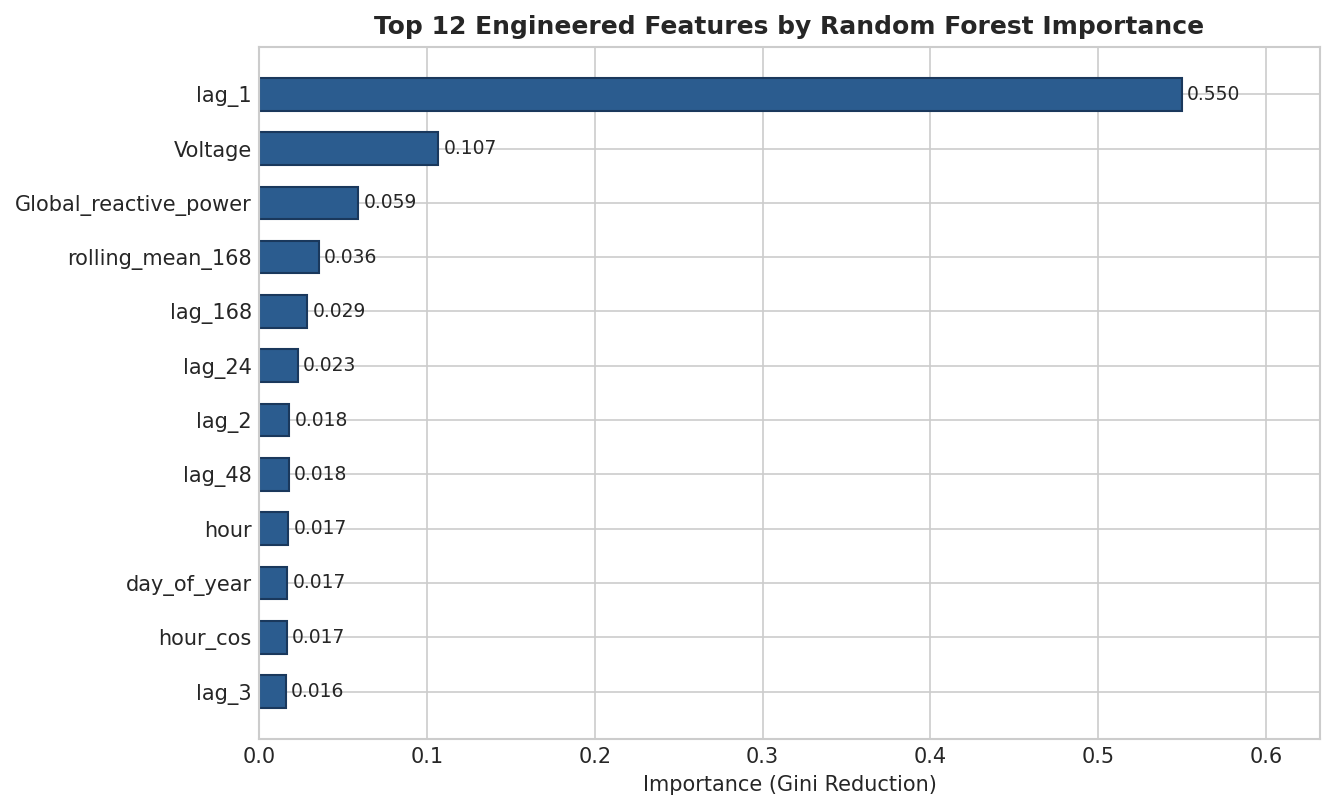

In [13]:
# Top Feature Importances
importances = tuned_rf.feature_importances_
fi_df = pd.DataFrame({'Feature': fe_cols, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5.5), dpi=150)
top_fi = fi_df.head(12).sort_values('Importance', ascending=True)
bars = plt.barh(top_fi['Feature'], top_fi['Importance'], color='#2b5c8f', edgecolor='#1a385c', height=0.6)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.003, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va='center', ha='left', fontsize=9)
plt.title('Top 12 Engineered Features by Random Forest Importance', fontweight='bold')
plt.xlabel('Importance (Gini Reduction)')
plt.xlim(0, max(top_fi['Importance']) * 1.15)
plt.tight_layout()
plt.show()


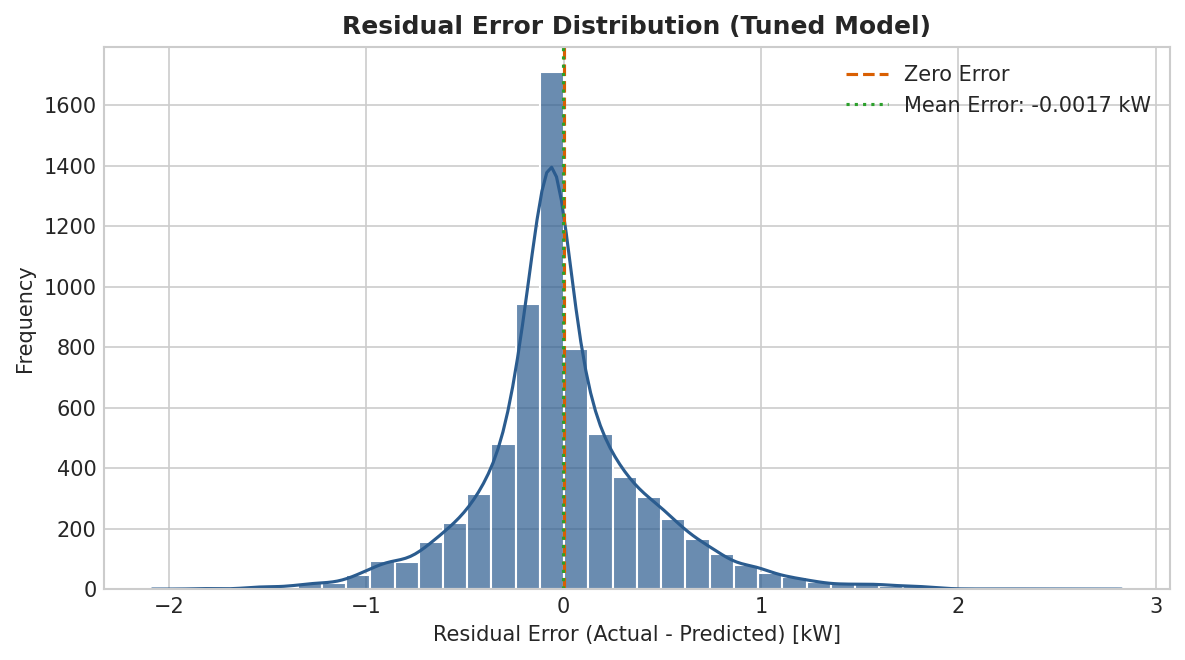

In [14]:
# Residual Error Distribution
residuals = y_te - y_pred_tuned
plt.figure(figsize=(8, 4.5), dpi=150)
sns.histplot(residuals, kde=True, color='#2b5c8f', bins=40, edgecolor='#ffffff', alpha=0.7)
plt.axvline(0, color='#d95f02', linestyle='--', lw=1.5, label='Zero Error')
plt.axvline(residuals.mean(), color='#2ca02c', linestyle=':', lw=1.5, label=f'Mean Error: {residuals.mean():.4f} kW')
plt.title('Residual Error Distribution (Tuned Model)', fontweight='bold')
plt.xlabel('Residual Error (Actual - Predicted) [kW]')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Conclusion & Key Takeaways
1. **Feature Engineering Impact:** Adding temporal, cyclical, lag, and rolling features was the primary driver of performance, increasing $R^2$ from 0.23 to >0.62 and reducing prediction errors by ~41%.
2. **Leakage Prevention:** Strict chronological train/test partitioning and applying rolling computations on `shift(1)` prevented future information from leaking into training features.
3. **Model Selection:** The non-linear Random Forest captured sharp appliance activation spikes that the linear baseline completely missed.
